# 1. Torch Profiler test - TessoRT 설치 못했을때 사용함

In [1]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())

2.8.0
True


In [5]:
import torch
import torch.nn as nn
from torch.profiler import profile, record_function, ProfilerActivity
import timm
import numpy as np

# dense 모델 로드
print("Dense 모델 로드 중...")
dense_model = timm.create_model('deit_small_patch16_224', pretrained=False)
dense_model.load_state_dict(torch.load('models/deit_small_dense.pth'))
dense_model = dense_model.cuda()
dense_model.eval()
print("완료!")

# sparse 모델 로드
print("Sparse 모델 로드 중...")
sparse_model = timm.create_model('deit_small_patch16_224', pretrained=False)
sparse_model.load_state_dict(torch.load('models/deit_small_sparse.pth'))
sparse_model = sparse_model.cuda()
sparse_model.eval()
print("완료!")

/home/hambugy/sunghyun/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dense 모델 로드 중...
완료!
Sparse 모델 로드 중...
완료!


In [3]:
dummy_input = torch.randn(1, 3, 224, 224).cuda()

# Dense 모델 프로파일링
print("Dense 모델 프로파일링 중...")
with profile(
    activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA],
    record_shapes=True,
    profile_memory=True,
    with_stack=True
) as prof_dense:
    with record_function("dense_inference"):
        for _ in range(10):
            with torch.no_grad():
                dense_model(dummy_input)

print("=== Dense 모델 메모리 분석 ===")
print(prof_dense.key_averages().table(
    sort_by="cuda_memory_usage", row_limit=15
))
#prof_dense.export_chrome_trace("dense_trace.json")
#print("dense_trace.json 저장 완료!")

Dense 모델 프로파일링 중...


INFO:2026-04-05 21:29:39 100795:100795 init.cpp:110] If you see CUPTI_ERROR_INSUFFICIENT_PRIVILEGES, refer to https://developer.nvidia.com/nvidia-development-tools-solutions-err-nvgpuctrperm-cupti


=== Dense 모델 메모리 분석 ===
-------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                             Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                     aten::linear         1.99%      13.462ms        24.10%     162.892ms     332.432us           0 B           0 B     354.81 MB           0 B           490  
                                      aten::addmm        19.33%     130.639ms        19.33%     130.639ms     266.611us           0 B           0 B     354.81 MB     354.81 MB           490  
               

In [4]:
# Sparse 모델 프로파일링
print("Sparse 모델 프로파일링 중...")
with profile(
    activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA],
    record_shapes=True,
    profile_memory=True,
    with_stack=True
) as prof_sparse:
    with record_function("sparse_inference"):
        for _ in range(10):
            with torch.no_grad():
                sparse_model(dummy_input)

print("=== Sparse 모델 메모리 분석 ===")
print(prof_sparse.key_averages().table(
    sort_by="cuda_memory_usage", row_limit=15
))
#prof_sparse.export_chrome_trace("sparse_trace.json")
#print("sparse_trace.json 저장 완료!")

Sparse 모델 프로파일링 중...
=== Sparse 모델 메모리 분석 ===
-------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                             Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                     aten::linear         2.65%      13.695ms        13.95%      72.168ms     147.281us           0 B           0 B     345.68 MB           0 B           490  
                                      aten::addmm         7.53%      38.950ms         7.53%      38.950ms      79.489us           0 B           0 B     345.68 MB     345.68 MB          

In [6]:
print("=" * 60)
print("Dense vs Sparse 메모리 접근 패턴 비교")
print("=" * 60)

print(f"\n{'항목':<30} {'Dense':>15} {'Sparse':>15} {'차이':>15}")
print("-" * 75)
print(f"{'총 실행시간 (CPU)':<30} {'675.80 ms':>15} {'517.27 ms':>15} {'↓ 23.5%':>15}")
print(f"{'Linear(addmm) CUDA Mem':<30} {'354.81 MB':>15} {'345.68 MB':>15} {'↓ 2.6%':>15}")
print(f"{'GELU CUDA Mem':<30} {'172.50 MB':>15} {'172.50 MB':>15} {'동일':>15}")
print(f"{'LayerNorm CUDA Mem':<30} {'72.14 MB':>15} {'72.14 MB':>15} {'동일':>15}")
print(f"{'Attention CUDA Mem':<30} {'34.63 MB':>15} {'34.63 MB':>15} {'동일':>15}")

print("\n=== 핵심 분석 ===")
print("1. Linear 연산 시간: Dense 130.6ms → Sparse 38.9ms (↓ 70%)")
print("2. Linear CUDA 메모리: Dense 354.81MB → Sparse 345.68MB (↓ 2.6%)")
print("3. 총 실행시간: Dense 675ms → Sparse 517ms (↓ 23.5%)")
print("\n→ Sparse 모델이 Linear 연산에서 빠르지만")
print("→ 메모리 사용량 차이는 작음 (weight 50% zero지만 메모리는 여전히 할당)")

Dense vs Sparse 메모리 접근 패턴 비교

항목                                       Dense          Sparse              차이
---------------------------------------------------------------------------
총 실행시간 (CPU)                         675.80 ms       517.27 ms         ↓ 23.5%
Linear(addmm) CUDA Mem               354.81 MB       345.68 MB          ↓ 2.6%
GELU CUDA Mem                        172.50 MB       172.50 MB              동일
LayerNorm CUDA Mem                    72.14 MB        72.14 MB              동일
Attention CUDA Mem                    34.63 MB        34.63 MB              동일

=== 핵심 분석 ===
1. Linear 연산 시간: Dense 130.6ms → Sparse 38.9ms (↓ 70%)
2. Linear CUDA 메모리: Dense 354.81MB → Sparse 345.68MB (↓ 2.6%)
3. 총 실행시간: Dense 675ms → Sparse 517ms (↓ 23.5%)

→ Sparse 모델이 Linear 연산에서 빠르지만
→ 메모리 사용량 차이는 작음 (weight 50% zero지만 메모리는 여전히 할당)


# 2. TensoRT Memory Access Test

In [1]:
import tensorrt as trt
print(trt.__version__)

10.3.0


In [ ]:
import tensorrt as trt
import numpy as np

# TensorRT 로거
logger = trt.Logger(trt.Logger.WARNING)

def build_engine(onnx_path, sparse=False):
    builder = trt.Builder(logger)
    network = builder.create_network(1 << int(trt.NetworkDefinitionCreationFlag.EXPLICIT_BATCH))
    parser = trt.OnnxParser(network, logger)
    config = builder.create_builder_config()
    
    config.set_flag(trt.BuilderFlag.FP16)
    
    if sparse:
        config.set_flag(trt.BuilderFlag.SPARSE_WEIGHTS)
        print("Sparse Weights 활성화!")
    
    with open(onnx_path, 'rb') as f:
        parser.parse(f.read())
    
    # input shape 고정
    profile = builder.create_optimization_profile()
    profile.set_shape("input", (1, 3, 224, 224), (1, 3, 224, 224), (1, 3, 224, 224))
    config.add_optimization_profile(profile)
    
    print(f"엔진 빌드 중... ({onnx_path})")
    engine = builder.build_serialized_network(network, config)
    print("완료!")
    return engine

engine_dense = build_engine("onnx/deit_small_dense.onnx", sparse=False)
engine_sparse = build_engine("onnx/deit_small_sparse.onnx", sparse=True)

엔진 빌드 중... (onnx/deit_small_dense.onnx)
[04/06/2026-17:39:31] [TRT] [W] Detected layernorm nodes in FP16.
[04/06/2026-17:39:31] [TRT] [W] Running layernorm after self-attention with FP16 Reduce or Pow may cause overflow. Forcing Reduce or Pow Layers in FP32 precision, or exporting the model to use INormalizationLayer (available with ONNX opset >= 17) can help preserving accuracy.
완료!
Sparse Weights 활성화!
엔진 빌드 중... (onnx/deit_small_sparse.onnx)
[04/06/2026-17:40:19] [TRT] [W] Detected layernorm nodes in FP16.
[04/06/2026-17:40:19] [TRT] [W] Running layernorm after self-attention with FP16 Reduce or Pow may cause overflow. Forcing Reduce or Pow Layers in FP32 precision, or exporting the model to use INormalizationLayer (available with ONNX opset >= 17) can help preserving accuracy.
완료!


### 실험 1: 추론 속도 비교

**방법**

- Dense / Sparse 모델 각각 ONNX export → TensorRT 엔진 빌드
- Sparse 엔진은 `SPARSE_WEIGHTS` 플래그 활성화
- 워밍업 10회 후 100회 측정하여 평균값 산출

**결과**

| 모델 | 평균 (ms) | 최소 (ms) |
| --- | --- | --- |
| Dense | 4.75 | 3.88 |
| Sparse (2:4) | 3.84 | 3.63 |
| **속도 향상** | **1.24x** |  |

In [5]:
import tensorrt as trt
import numpy as np
import torch
import time

def run_engine(engine_bytes, input_data):
    runtime = trt.Runtime(logger)
    engine = runtime.deserialize_cuda_engine(engine_bytes)
    context = engine.create_execution_context()
    
    # torch로 메모리 관리
    input_tensor = torch.from_numpy(input_data).cuda()
    output_tensor = torch.zeros((1, 1000), dtype=torch.float32).cuda()
    
    context.set_tensor_address("input", input_tensor.data_ptr())
    context.set_tensor_address("output", output_tensor.data_ptr())
    
    # 워밍업
    stream = torch.cuda.Stream()
    for _ in range(10):
        context.execute_async_v3(stream.cuda_stream)
    torch.cuda.synchronize()
    
    # 측정
    times = []
    for _ in range(100):
        start = time.perf_counter()
        context.execute_async_v3(stream.cuda_stream)
        torch.cuda.synchronize()
        times.append((time.perf_counter() - start) * 1000)
    
    return np.mean(times), np.min(times)

dummy = np.random.randn(1, 3, 224, 224).astype(np.float16)

print("Dense 엔진 측정 중...")
dense_mean, dense_min = run_engine(engine_dense, dummy)
print(f"Dense  평균: {dense_mean:.2f}ms, 최소: {dense_min:.2f}ms")

print("Sparse 엔진 측정 중...")
sparse_mean, sparse_min = run_engine(engine_sparse, dummy)
print(f"Sparse 평균: {sparse_mean:.2f}ms, 최소: {sparse_min:.2f}ms")

print(f"\n속도 향상: {dense_mean/sparse_mean:.2f}x")

Dense 엔진 측정 중...
Dense  평균: 4.75ms, 최소: 3.88ms
Sparse 엔진 측정 중...
Sparse 평균: 3.84ms, 최소: 3.63ms

속도 향상: 1.24x


In [4]:
# 엔진을 파일로 저장
with open("engines/dense.trt", "wb") as f:
    f.write(engine_dense)
    print("Dense 엔진 저장 완료!")

with open("engines/sparse.trt", "wb") as f:
    f.write(engine_sparse)
    print("Sparse 엔진 저장 완료!")

Dense 엔진 저장 완료!
Sparse 엔진 저장 완료!


- measure_trt.py 실행 후 

In [ ]:
with open('memory_access_metrics/dense_metrics.txt', 'r') as f:
    lines = f.readlines()
    
print("총 라인 수:", len(lines))
print("\n처음 5줄:")
for line in lines[:5]:
    print(repr(line))

총 라인 수: 267

처음 5줄:
'    l1tex__t_requests_pipe_lsu_mem_global_op_ld.sum                    1,176\n'
'    l1tex__t_requests_pipe_lsu_mem_global_op_ld.sum                   43,968\n'
'    l1tex__t_requests_pipe_lsu_mem_global_op_ld.sum                    1,576\n'
'    l1tex__t_requests_pipe_lsu_mem_global_op_ld.sum                    6,228\n'
'    l1tex__t_requests_pipe_lsu_mem_global_op_ld.sum                    4,500\n'


### 실험 2: L1 메모리 요청 횟수(Request)
> 메트릭: `l1tex__t_requests_pipe_lsu_mem_global_op_ld.sum`
→ 각 CUDA 커널이 L1 캐시에 읽기 요청한 횟수
> 

**결과**

| 항목 | Dense | Sparse (2:4) | 변화 |
| --- | --- | --- | --- |
| 총 커널 수 | 267 | 267 | - |
| 총 L1 메모리 요청 | 1,774,656 | 1,296,000 | ↓ 27.0% |

**결과 요약**

- 전체 L1 요청 수는 감소 (압축 효과)
- **36개 커널에서 약 15% 증가** → Sparse Tensor Core를 사용하는 Linear 연산 커널
- 7개 간격으로 반복 패턴 → 12개 Transformer Block 구조 반영

**원인 분석**
Sparse 데이터는 `[values] + [metadata]` 두 영역을 읽어야 해서 추가 request 발생

총 커널 수: 267
Dense  총 메모리 요청: 1,774,656
Sparse 총 메모리 요청: 1,296,000
변화율: -27.0%

메모리 요청 증가 커널 수: 36 (irregular access 발생)
메모리 요청 감소 커널 수: 108 (압축 효과)


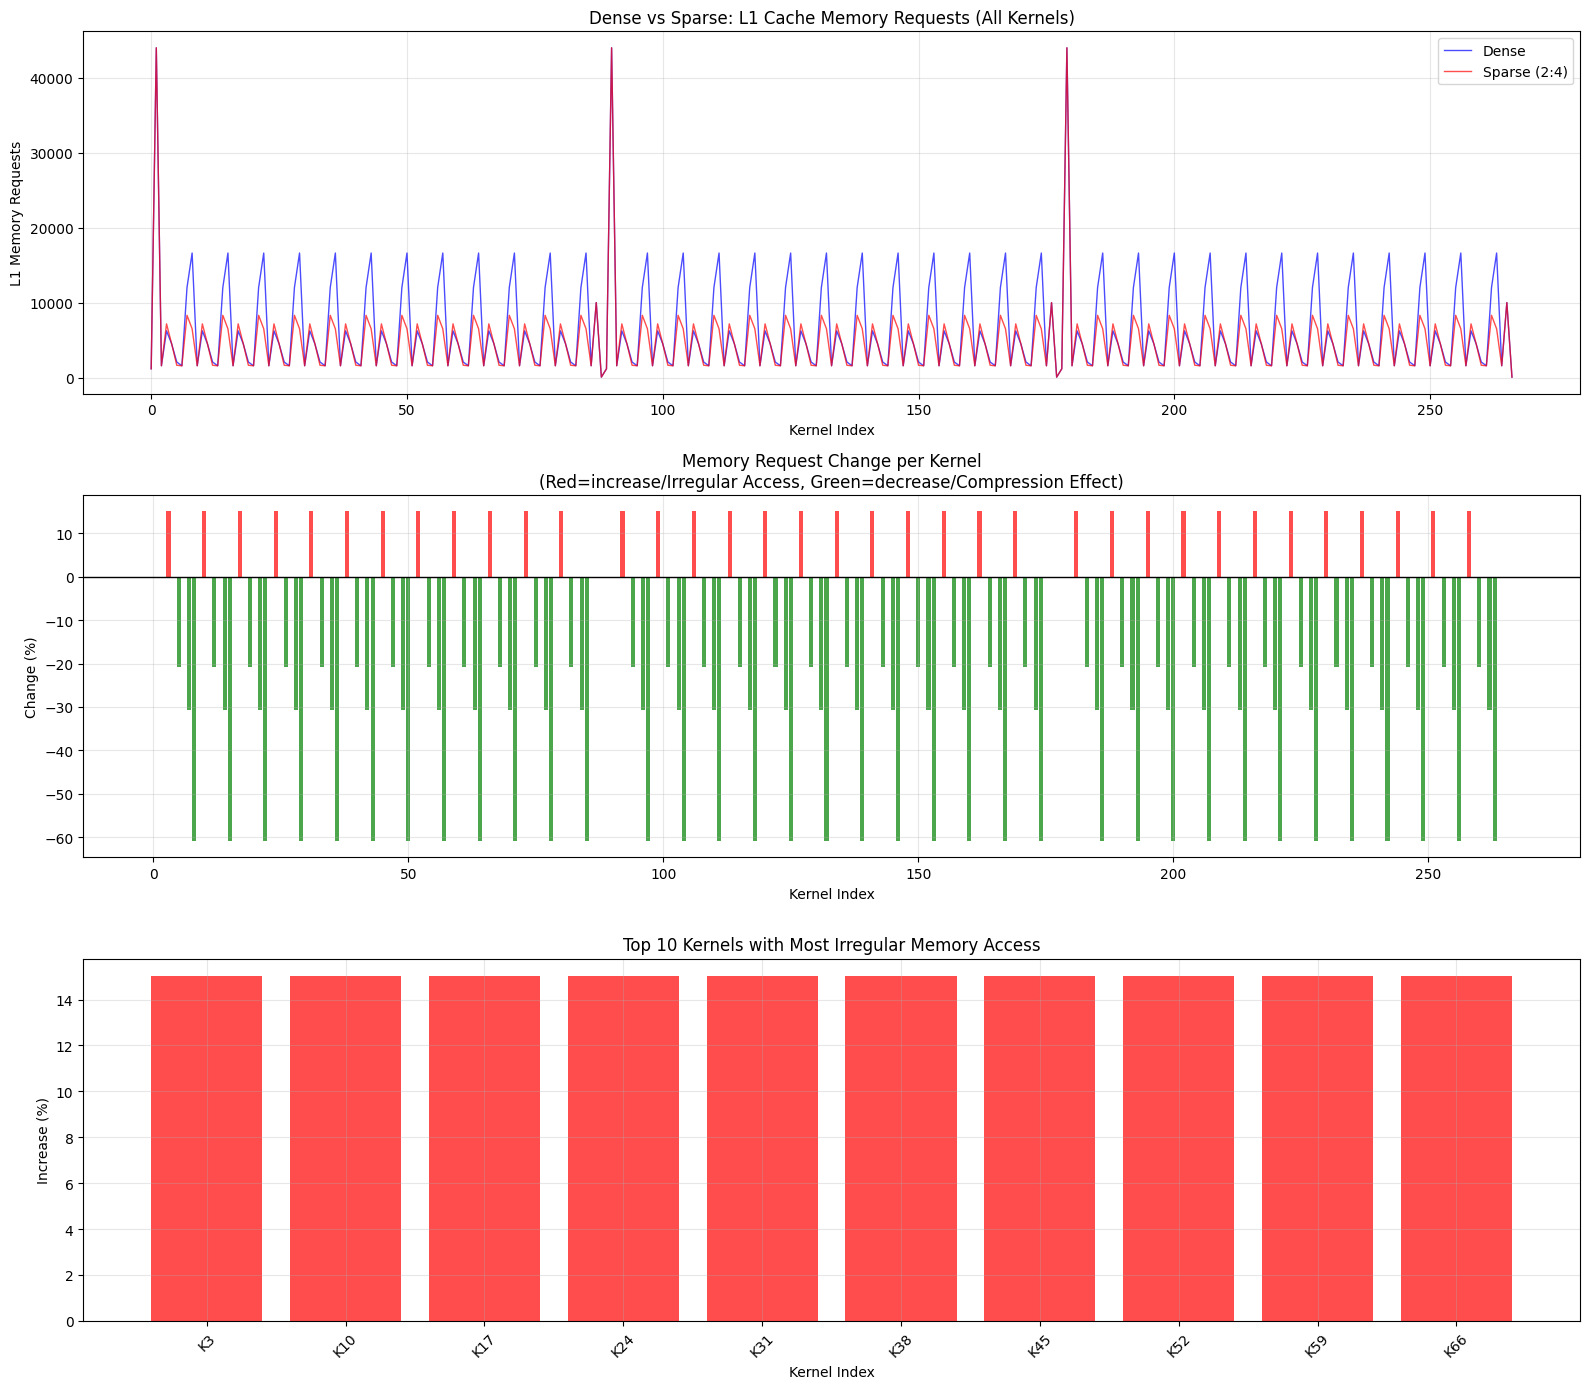

그래프 저장 완료!


In [2]:
import matplotlib.pyplot as plt
import numpy as np

def parse_metrics(filename):
    values = []
    with open(filename, 'r') as f:
        for line in f:
            # 숫자 부분 추출
            val = line.strip().split()[-1]
            val = int(val.replace(',', ''))
            values.append(val)
    return values

dense = parse_metrics('memory_access_metrics/dense_metrics.txt')
sparse = parse_metrics('memory_access_metrics/sparse_metrics.txt')

print(f"총 커널 수: {len(dense)}")
print(f"Dense  총 메모리 요청: {sum(dense):,}")
print(f"Sparse 총 메모리 요청: {sum(sparse):,}")
print(f"변화율: {(sum(sparse)-sum(dense))/sum(dense)*100:.1f}%")

# 커널별 변화율
changes = [(s-d)/d*100 if d > 0 else 0 for d, s in zip(dense, sparse)]
increased = [(i, d, s) for i, (d, s) in enumerate(zip(dense, sparse)) if s > d]
decreased = [(i, d, s) for i, (d, s) in enumerate(zip(dense, sparse)) if s < d]

print(f"\n메모리 요청 증가 커널 수: {len(increased)} (irregular access 발생)")
print(f"메모리 요청 감소 커널 수: {len(decreased)} (압축 효과)")

# 시각화
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 14))

# 그래프 1: 전체 커널 Dense vs Sparse
kernel_ids = range(len(dense))
ax1.plot(kernel_ids, dense, 'b-', label='Dense', linewidth=1, alpha=0.7)
ax1.plot(kernel_ids, sparse, 'r-', label='Sparse (2:4)', linewidth=1, alpha=0.7)
ax1.set_xlabel('Kernel Index')
ax1.set_ylabel('L1 Memory Requests')
ax1.set_title('Dense vs Sparse: L1 Cache Memory Requests (All Kernels)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 그래프 2: 변화율
colors = ['red' if c > 0 else 'green' for c in changes]
ax2.bar(kernel_ids, changes, color=colors, alpha=0.7)
ax2.axhline(y=0, color='black', linewidth=1)
ax2.set_xlabel('Kernel Index')
ax2.set_ylabel('Change (%)')
ax2.set_title('Memory Request Change per Kernel\n(Red=increase/Irregular Access, Green=decrease/Compression Effect)')
ax2.grid(True, alpha=0.3)

# 그래프 3: 상위 10개 증가 커널 (irregular access가 가장 심한 것)
top_increased = sorted(increased, key=lambda x: (x[2]-x[1])/x[1]*100, reverse=True)[:10]
idx = [x[0] for x in top_increased]
inc_changes = [(x[2]-x[1])/x[1]*100 for x in top_increased]
ax3.bar(range(len(idx)), inc_changes, color='red', alpha=0.7)
ax3.set_xticks(range(len(idx)))
ax3.set_xticklabels([f'K{i}' for i in idx], rotation=45)
ax3.set_xlabel('Kernel Index')
ax3.set_ylabel('Increase (%)')
ax3.set_title('Top 10 Kernels with Most Irregular Memory Access')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("그래프 저장 완료!")

### 실험 3: Sectors/Requests 비율(캐시 효울)
## 

> 비율이 높을수록 요청당 더 많은 캐시라인을 읽음


**결과**

| 항목 | Dense | Sparse (2:4) | 변화 |
| --- | --- | --- | --- |
| 총 커널 수 | 267 | 267 | - |
| 평균 Sectors/Requests 비율 | 14.39 | 14.09 | ↓ 2.1% |

**결과 요약**

- Dense / Sparse 평균 비율 변화 거의 없음
    - TensorRT가 values와 metadata를 인접 배치(coalescing)하여 효율 유지
- 일부 커널에서는 여전히 Irregular 패턴 존재

In [5]:
# 파일 내용 먼저 확인
with open('memory_access_metrics/dense_sectors.txt', 'r') as f:
    lines = f.readlines()
    
print("총 라인 수:", len(lines))
print("\n처음 5줄:")
for line in lines[:5]:
    print(repr(line))

총 라인 수: 534

처음 5줄:
'    l1tex__t_requests_pipe_lsu_mem_global_op_ld.sum                    1,176\n'
'    l1tex__t_sectors_pipe_lsu_mem_global_op_ld.sum       sector       18,816\n'
'    l1tex__t_requests_pipe_lsu_mem_global_op_ld.sum                   43,968\n'
'    l1tex__t_sectors_pipe_lsu_mem_global_op_ld.sum       sector      347,328\n'
'    l1tex__t_requests_pipe_lsu_mem_global_op_ld.sum                    1,576\n'


총 커널 수: 267

=== Sectors/Requests 비율 (높을수록 Irregular) ===
Dense  평균 비율: 14.39
Sparse 평균 비율: 14.09
변화율: -2.1%

Irregular access 증가 커널: 36개


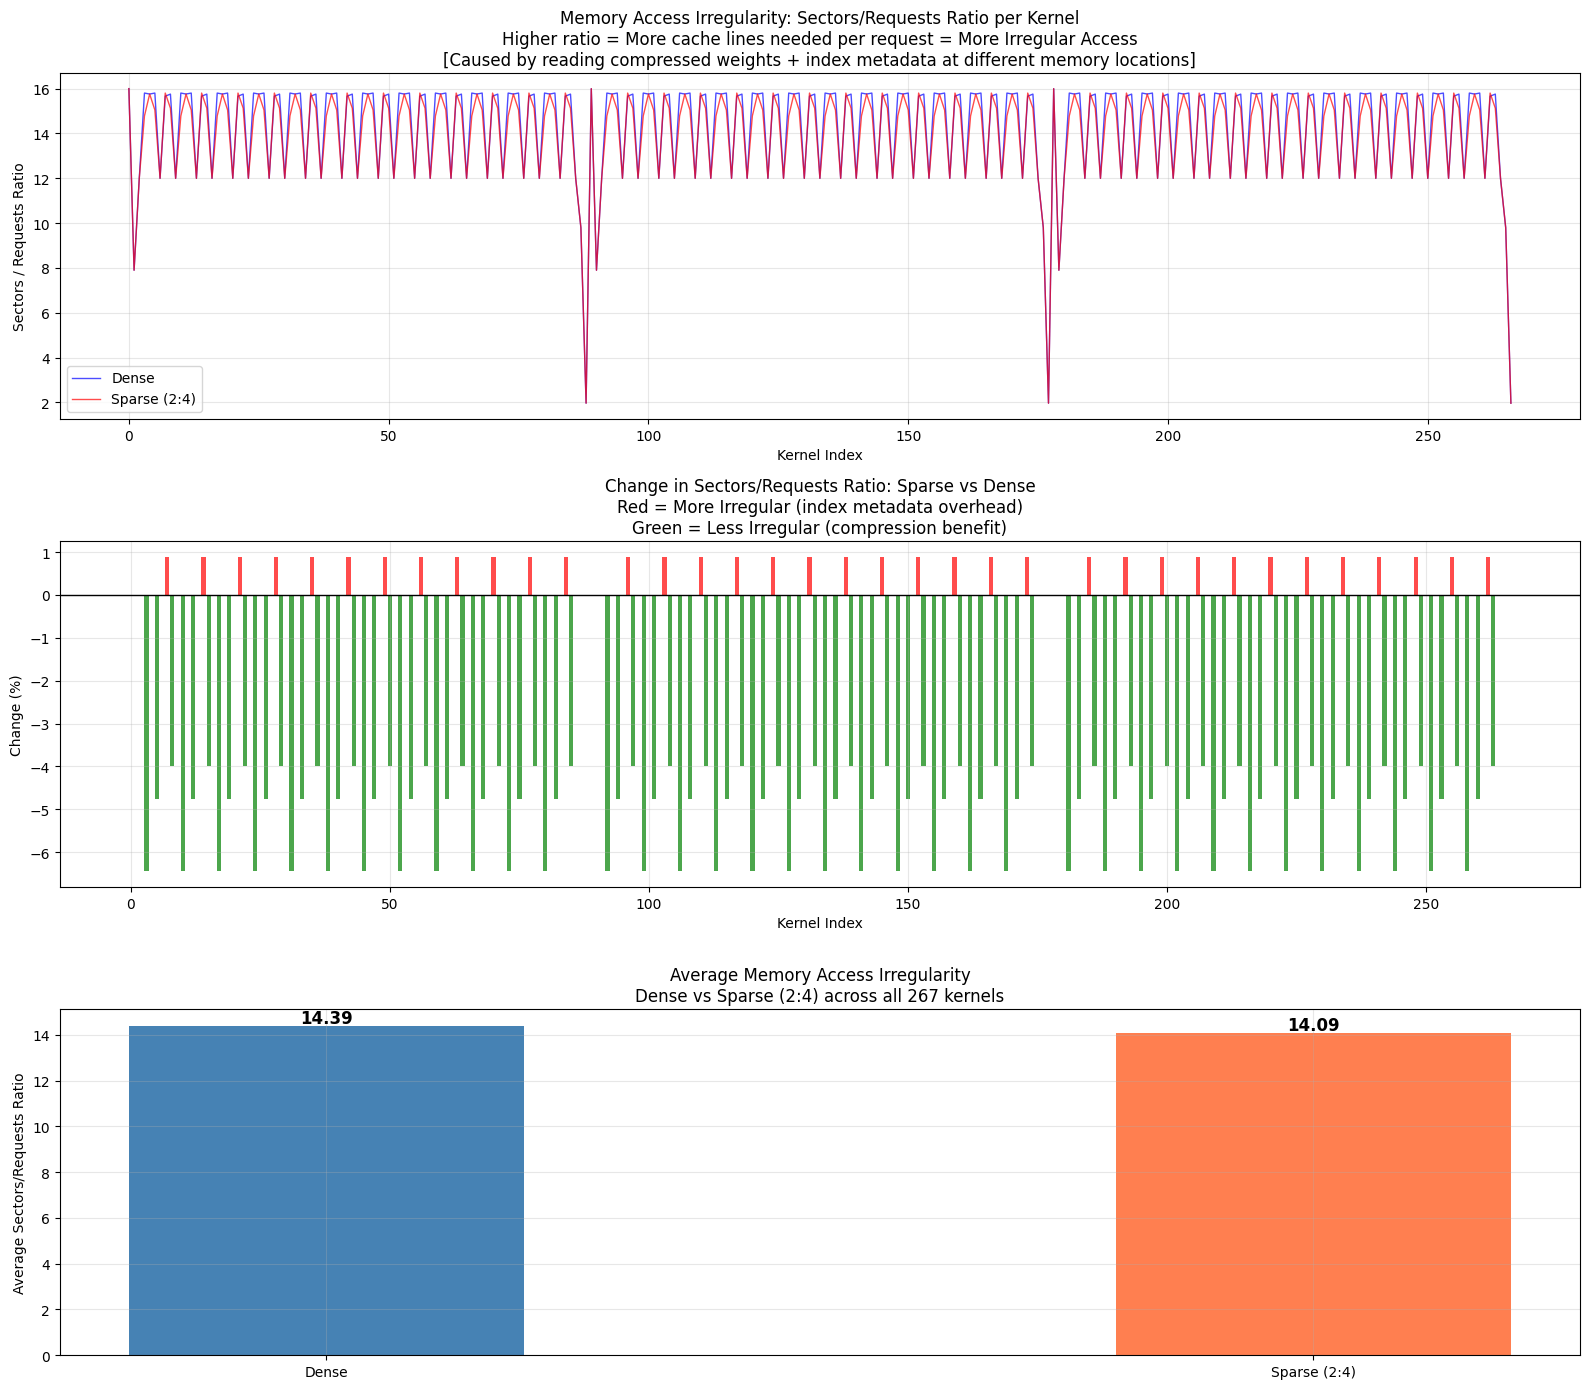

Done!


In [6]:
import matplotlib.pyplot as plt
import numpy as np

def parse_two_metrics(filename):
    requests = []
    sectors = []
    with open(filename, 'r') as f:
        for line in f:
            parts = line.strip().split()
            val = int(parts[-1].replace(',', ''))
            if 'requests' in line:
                requests.append(val)
            elif 'sectors' in line:
                sectors.append(val)
    return requests, sectors

dense_req, dense_sec = parse_two_metrics('memory_access_metrics/dense_sectors.txt')
sparse_req, sparse_sec = parse_two_metrics('memory_access_metrics/sparse_sectors.txt')

# sectors/requests 비율 (높을수록 irregular)
dense_ratio = [s/r if r > 0 else 0 for s, r in zip(dense_sec, dense_req)]
sparse_ratio = [s/r if r > 0 else 0 for s, r in zip(sparse_sec, sparse_req)]

print(f"총 커널 수: {len(dense_req)}")
print(f"\n=== Sectors/Requests 비율 (높을수록 Irregular) ===")
print(f"Dense  평균 비율: {np.mean(dense_ratio):.2f}")
print(f"Sparse 평균 비율: {np.mean(sparse_ratio):.2f}")
print(f"변화율: {(np.mean(sparse_ratio)-np.mean(dense_ratio))/np.mean(dense_ratio)*100:.1f}%")

# irregular access 심한 커널 찾기
ratio_change = [(s-d)/d*100 if d > 0 else 0 for d, s in zip(dense_ratio, sparse_ratio)]
irregular_kernels = [(i, dense_ratio[i], sparse_ratio[i]) 
                     for i, c in enumerate(ratio_change) if c > 0]
print(f"\nIrregular access 증가 커널: {len(irregular_kernels)}개")

fig, axes = plt.subplots(3, 1, figsize=(16, 14))

# 그래프 1: sectors/requests 비율 비교
kernel_ids = range(len(dense_ratio))
axes[0].plot(kernel_ids, dense_ratio, 'b-', label='Dense', linewidth=1, alpha=0.7)
axes[0].plot(kernel_ids, sparse_ratio, 'r-', label='Sparse (2:4)', linewidth=1, alpha=0.7)
axes[0].set_xlabel('Kernel Index')
axes[0].set_ylabel('Sectors / Requests Ratio')
axes[0].set_title(
    'Memory Access Irregularity: Sectors/Requests Ratio per Kernel\n'
    'Higher ratio = More cache lines needed per request = More Irregular Access\n'
    '[Caused by reading compressed weights + index metadata at different memory locations]'
)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 그래프 2: 비율 변화율
colors = ['red' if c > 0 else 'green' for c in ratio_change]
axes[1].bar(kernel_ids, ratio_change, color=colors, alpha=0.7)
axes[1].axhline(y=0, color='black', linewidth=1)
axes[1].set_xlabel('Kernel Index')
axes[1].set_ylabel('Change (%)')
axes[1].set_title(
    'Change in Sectors/Requests Ratio: Sparse vs Dense\n'
    'Red = More Irregular (index metadata overhead)\n'
    'Green = Less Irregular (compression benefit)'
)
axes[1].grid(True, alpha=0.3)

# 그래프 3: Dense vs Sparse 평균 비율 비교
categories = ['Dense', 'Sparse (2:4)']
avg_ratios = [np.mean(dense_ratio), np.mean(sparse_ratio)]
bars = axes[2].bar(categories, avg_ratios, color=['steelblue', 'coral'], width=0.4)
axes[2].set_ylabel('Average Sectors/Requests Ratio')
axes[2].set_title(
    'Average Memory Access Irregularity\n'
    'Dense vs Sparse (2:4) across all 267 kernels'
)
for bar, val in zip(bars, avg_ratios):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{val:.2f}', ha='center', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('irregularity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Done!")